### 1. (a) Implement a single-layer perceptron for binary classification using PyTorch. 

Epoch [10/100], Loss: 0.5547
Epoch [20/100], Loss: 0.4560
Epoch [30/100], Loss: 0.3943
Epoch [40/100], Loss: 0.3521
Epoch [50/100], Loss: 0.3214
Epoch [60/100], Loss: 0.2979
Epoch [70/100], Loss: 0.2792
Epoch [80/100], Loss: 0.2641
Epoch [90/100], Loss: 0.2515
Epoch [100/100], Loss: 0.2408


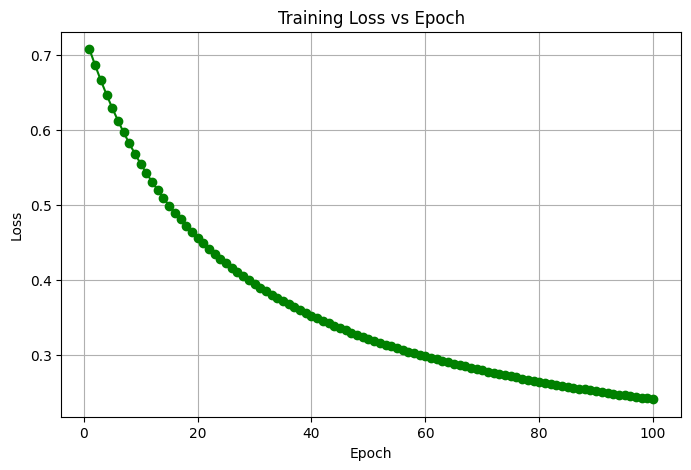


Test Accuracy: 95.61%


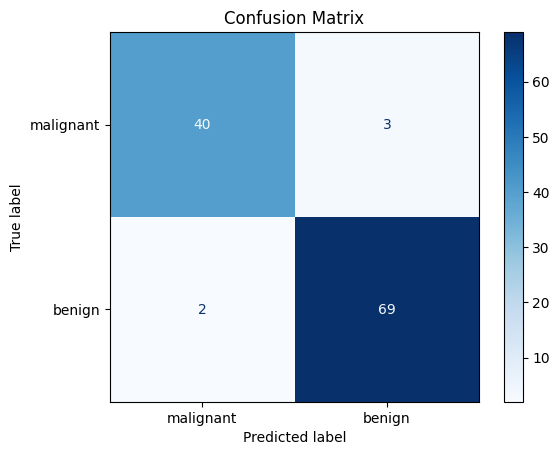

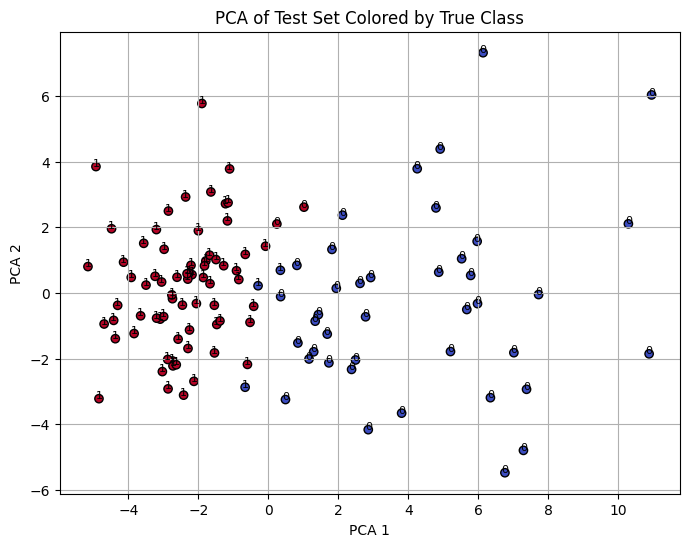

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target  # Binary labels: 0 = malignant, 1 = benign

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Define the single-layer perceptron model
class SingleLayerPerceptron(nn.Module):
    def __init__(self, input_dim):
        super(SingleLayerPerceptron, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Initialize model, loss, optimizer
model = SingleLayerPerceptron(input_dim=X.shape[1])
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop with loss tracking
epochs = 100
loss_values = []
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss_values.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Plot training loss vs. epoch
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_values, color='green', marker='o')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Evaluate on test set
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_label = (y_pred >= 0.5).float()
    accuracy = (y_pred_label == y_test_tensor).float().mean()
    print(f'\nTest Accuracy: {accuracy.item() * 100:.2f}%')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_label.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# PCA Visualization
pca = PCA(n_components=2)
X_test_2D = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', label='True Labels')
plt.title("PCA of Test Set Colored by True Class")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Show predicted labels in red or blue
for i in range(len(y_pred_label)):
    plt.text(X_test_2D[i, 0], X_test_2D[i, 1], str(int(y_pred_label[i].item())),
             fontsize=8, color='black', ha='center')

plt.grid(True)
plt.show()


### 1.(b) Write a program to classify data from three different classes using a multi-layer neural 	network. 

Epoch [10/100], Loss: 0.8701
Epoch [20/100], Loss: 0.5965
Epoch [30/100], Loss: 0.4356
Epoch [40/100], Loss: 0.3531
Epoch [50/100], Loss: 0.2990
Epoch [60/100], Loss: 0.2545
Epoch [70/100], Loss: 0.2137
Epoch [80/100], Loss: 0.1774
Epoch [90/100], Loss: 0.1475
Epoch [100/100], Loss: 0.1244


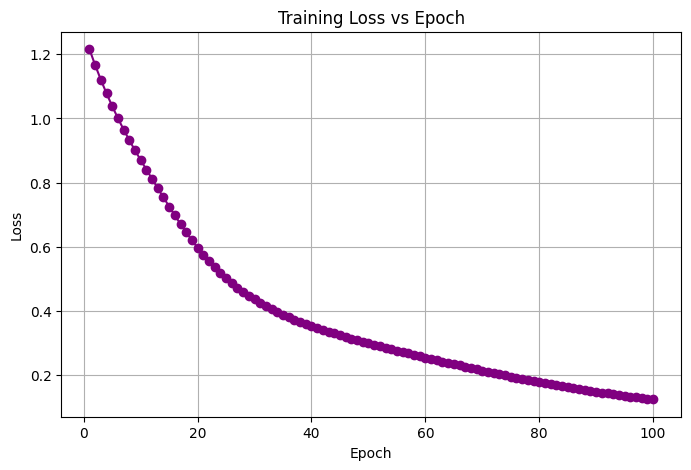


Test Accuracy: 100.00%


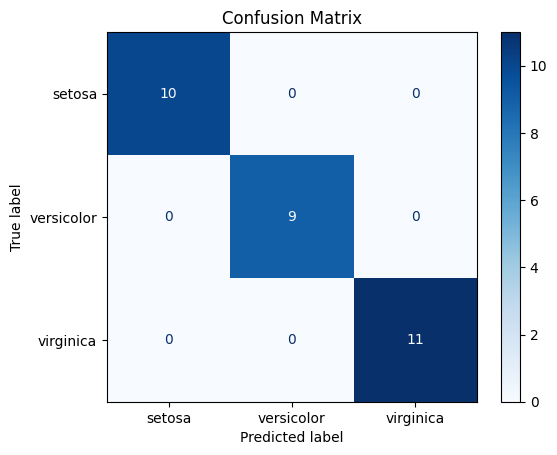

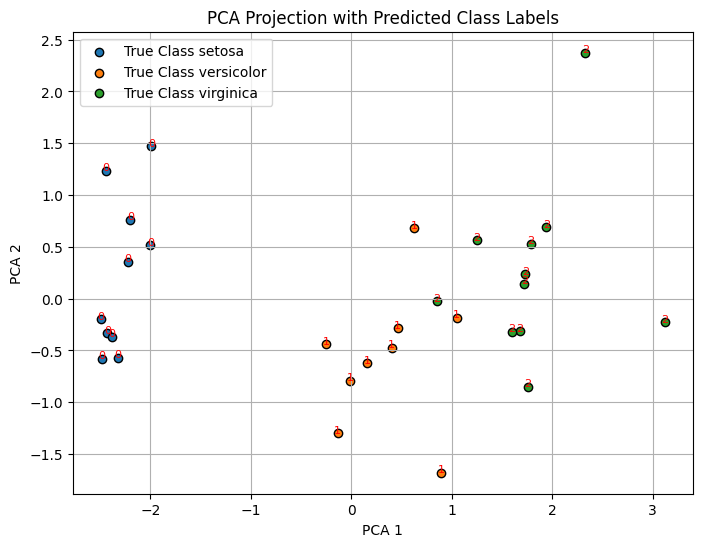

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data  # 4 features
y = iris.target  # Classes: 0, 1, 2

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out  # raw logits for CrossEntropyLoss

# Initialize model, loss, optimizer
model = MLP(input_dim=4, hidden_dim=10, output_dim=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop with loss tracking
epochs = 100
loss_values = []

for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss_values.append(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Plot training loss vs. epoch
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_values, marker='o', color='purple')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Evaluation
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    y_pred_labels = torch.argmax(y_pred_logits, dim=1)

# Accuracy
#acc = accuracy_score(y_test, y_pred_labels)
acc = accuracy_score(y_test, y_pred_labels.numpy())

print(f"\nTest Accuracy: {acc * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# PCA Visualization
pca = PCA(n_components=2)
X_test_2D = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y_test)):
    plt.scatter(X_test_2D[y_test == label, 0], X_test_2D[y_test == label, 1],
                label=f"True Class {iris.target_names[label]}", edgecolor='k')

for i in range(len(y_pred_labels)):
    plt.text(X_test_2D[i, 0], X_test_2D[i, 1], str(y_pred_labels[i].item()),
             color='red', fontsize=8, ha='center')

plt.title("PCA Projection with Predicted Class Labels")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()
